# Proyek Klasifikasi Gambar: [Vegetable Image Dataset]
- **Nama:** Firda Zahra Wahyu Sagita Putri
- **Email:** m891d5x0649@student.devacademy.id atau firda.zahraputri@gmail.com
- **ID Dicoding:** M891D5X0649


## Import Semua Packages/Library yang Digunakan

In [ ]:
!pip install tensorflowjs

In [ ]:
!pip install kagglehub

In [ ]:
# Melakukan Import Library yang dibutuhkan
import os, json, random, shutil, zipfile, pathlib, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import kagglehub
from PIL import Image
from google.colab import files

import tensorflow as tf
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger)
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from keras.layers import TFSMLayer
import itertools
import tensorflowjs as tfjs
import warnings
warnings.filterwarnings('ignore')

## Data Preparation

In [ ]:
# Melakukan Download dataset dari Kaggle
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

print("Path ke dataset:", path)
print("Isi folder:", os.listdir(path))

# Membuat direktori utama dataset
base_dir = os.path.join(path, "Vegetable Images")

# Membuat folder asli dataset
train_dir_original = os.path.join(base_dir, "train")
test_dir_original = os.path.join(base_dir, "test")
valid_dir_original = os.path.join(base_dir, "validation")

print("Folder asli:")
print("Train :", train_dir_original)
print("Test  :", test_dir_original)
print("Valid :", valid_dir_original)


Using Colab cache for faster access to the 'vegetable-image-dataset' dataset.
Path ke dataset: /kaggle/input/vegetable-image-dataset
Isi folder: ['Vegetable Images']
Folder asli:
Train : /kaggle/input/vegetable-image-dataset/Vegetable Images/train
Test  : /kaggle/input/vegetable-image-dataset/Vegetable Images/test
Valid : /kaggle/input/vegetable-image-dataset/Vegetable Images/validation


In [ ]:
# Membuat folder untuk menyimpan keseluruhan data
all_data_dir = "/content/all_data"

if not os.path.exists(all_data_dir):
    os.makedirs(all_data_dir)

# Menggabungkan seluruh gambar dari train, test, validation
for split_dir in [train_dir_original, test_dir_original, valid_dir_original]:
    for class_name in os.listdir(split_dir):
        class_path = os.path.join(split_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        # Membuat folder kelas di all_data
        target_class_path = os.path.join(all_data_dir, class_name)
        os.makedirs(target_class_path, exist_ok=True)

        # Menyalin semua gambar ke folder all_data
        for img_file in os.listdir(class_path):
            src = os.path.join(class_path, img_file)
            dst = os.path.join(target_class_path, img_file)

            shutil.copy(src, dst)

print("Semua gambar berhasil digabungkan ke:", all_data_dir)

Semua gambar berhasil digabungkan ke: /content/all_data


### Data Loading

In [ ]:
# Menghitung jumlah gambar dan kelas
def count_images(folder):
    total = 0
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            total += len(os.listdir(cls_path))
    return total

print("Jumlah total gambar :", count_images(all_data_dir))
print("Kelas:", os.listdir(all_data_dir))

Jumlah total gambar : 21000
Kelas: ['Cucumber', 'Broccoli', 'Radish', 'Bottle_Gourd', 'Carrot', 'Pumpkin', 'Potato', 'Papaya', 'Bean', 'Brinjal', 'Cauliflower', 'Bitter_Gourd', 'Capsicum', 'Cabbage', 'Tomato']


In [ ]:
# Membuat fungsi untuk menampilkan resolusi gambar
def print_images_resolution(directory):
    print("Hasil resolusi gambar dari tiap kelas:\n")
    total_images = 0

    if not os.path.exists(directory):
        print(f"Folder {directory} tidak ditemukan.")
        return

    # Melakukan loop setiap folder kelas dalam all_data_dir
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):
            continue

        # Menghitung file gambar valid
        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        num_images = len(image_files)
        total_images += num_images

        print(f"{class_name}: {num_images} gambar")

        unique_sizes = set()

        # Membaca ukuran setiap gambar
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            try:
                with Image.open(img_path) as img:
                    unique_sizes.add(img.size)  # (width, height)
            except Exception as e:
                print(f"  Gagal membaca {img_file}: {e}")

        # Mencetak ukuran
        if unique_sizes:
            print("  Ukuran gambar unik:")
            for size in sorted(unique_sizes):
                print(f"   - {size}")
        else:
            print("  (Tidak ada gambar valid ditemukan)")

        print("-" * 40)

    print(f"\nTotal gambar di semua kelas: {total_images}")

print_images_resolution(all_data_dir)

Hasil resolusi gambar dari tiap kelas:

Bean: 1400 gambar
  Ukuran gambar unik:
   - (224, 224)
----------------------------------------
Bitter_Gourd: 1400 gambar
  Ukuran gambar unik:
   - (224, 193)
   - (224, 200)
   - (224, 205)
   - (224, 224)
----------------------------------------
Bottle_Gourd: 1400 gambar
  Ukuran gambar unik:
   - (224, 224)
----------------------------------------
Brinjal: 1400 gambar
  Ukuran gambar unik:
   - (224, 224)
----------------------------------------
Broccoli: 1400 gambar
  Ukuran gambar unik:
   - (224, 224)
----------------------------------------
Cabbage: 1400 gambar
  Ukuran gambar unik:
   - (224, 224)
----------------------------------------
Capsicum: 1400 gambar
  Ukuran gambar unik:
   - (224, 224)
----------------------------------------
Carrot: 1400 gambar
  Ukuran gambar unik:
   - (224, 224)
----------------------------------------
Cauliflower: 1400 gambar
  Ukuran gambar unik:
   - (224, 224)
----------------------------------------


In [ ]:
# Menampilkan kelas yang memiliki data tidak seragam
resolutions = {}

for subdir in os.listdir(all_data_dir):
    subdir_path = os.path.join(all_data_dir, subdir)

    if os.path.isdir(subdir_path):
        unique_sizes = set()

        for img_file in os.listdir(subdir_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(subdir_path, img_file)
                try:
                    with Image.open(img_path) as img:
                        unique_sizes.add(img.size)
                except:
                    pass

        resolutions[subdir] = unique_sizes

print("Kelas dengan ukuran gambar tidak seragam:")
for kelas, sizes in resolutions.items():
    if len(sizes) > 1:
        print(f"- {kelas}: {sizes}")

Kelas dengan ukuran gambar tidak seragam:
- Papaya: {(224, 211), (224, 224), (224, 198), (224, 223), (224, 207), (224, 210), (224, 187)}
- Bitter_Gourd: {(224, 224), (224, 193), (224, 205), (224, 200)}


### Data Preprocessing

In [ ]:
# Menentukan ukuran gambar dan ukuran data per batch
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Melakukan augmentasi untuk data training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Melakukan normalisasi untuk data validasi dan  testing
val_test_datagen = ImageDataGenerator(rescale=1./255)

#### Split Dataset

In [ ]:
# Mengambil path gambar
filepaths = []
labels = []

for cls in os.listdir(all_data_dir):
    cls_path = os.path.join(all_data_dir, cls)
    for img_file in os.listdir(cls_path):
        filepaths.append(os.path.join(cls_path, img_file))
        labels.append(cls)

total = len(filepaths)
print("Total data:", total)

# Melakukan split data menjadi 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

train_count = len(X_train)
val_count   = len(X_val)
test_count  = len(X_test)

print("\nJumlah data")
print(f"Train : {train_count}  ({train_count/total*100:.2f}%)")
print(f"Valid : {val_count}   ({val_count/total*100:.2f}%)")
print(f"Test  : {test_count}   ({test_count/total*100:.2f}%)")

Total data: 21000

Jumlah data
Train : 14700  (70.00%)
Valid : 3150   (15.00%)
Test  : 3150   (15.00%)


#### Data Final

In [ ]:
# Membuat folder train, test, dan validasi
split_base = "/content/split_data"
train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "validation")
test_dir = os.path.join(split_base, "test")

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# Membuat fungsi untuk salin file sesuai subset
def copy_to_split(file_list, label_list, target_dir):
    for fp, cls in zip(file_list, label_list):
        cls_path = os.path.join(target_dir, cls)
        os.makedirs(cls_path, exist_ok=True)
        shutil.copy(fp, os.path.join(cls_path, os.path.basename(fp)))

copy_to_split(X_train, y_train, train_dir)
copy_to_split(X_val, y_val, val_dir)
copy_to_split(X_test, y_test, test_dir)

print("Dataset berhasil disalin ke folder baru")

Dataset berhasil disalin ke folder baru


In [ ]:
# Membuat generator untuk data training
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# Membuat generator untuk data validation
val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Membuat generator untuk data testing
test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

# Menampilkan jumlah dan mapping kelas
NUM_CLASSES = len(train_gen.class_indices)
idx_to_class = {v:k for k,v in train_gen.class_indices.items()}

print("Jumlah kelas:", NUM_CLASSES)
print("Mapping kelas:")

for idx, class_name in idx_to_class.items():
    print(f"{idx} : {class_name}")

Found 14700 images belonging to 15 classes.
Found 3150 images belonging to 15 classes.
Found 3150 images belonging to 15 classes.
Jumlah kelas: 15
Mapping kelas:
0 : Bean
1 : Bitter_Gourd
2 : Bottle_Gourd
3 : Brinjal
4 : Broccoli
5 : Cabbage
6 : Capsicum
7 : Carrot
8 : Cauliflower
9 : Cucumber
10 : Papaya
11 : Potato
12 : Pumpkin
13 : Radish
14 : Tomato


## Modelling

In [ ]:
# Membuat fungsi untuk membangun model CNN
def build_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES):
    model = Sequential(name="Vegetable_CNN_Model")

    # Block 1
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    # Block 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    # Block 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.35))

    # Block 4
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.4))

    # Fully connected
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Membuat model
model = build_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

# Melihat ringkasan model
model.summary()

Model: "Vegetable_CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,088,655 (99.52 MB)

 Trainable params: 26,087,695 (99.52 MB)

 Non-trainable params: 960 (3.75 KB)

## Evaluasi dan Visualisasi

In [ ]:
# Membuat folder untuk menyimpan hasil training
os.makedirs("/content/exports", exist_ok=True)

# Membuat Callback
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint("/content/exports/best_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
    CSVLogger("/content/exports/training_log.csv")
]

In [ ]:
# Melakukan training model
EPOCHS = 40

# Melatih model dengan data training dan validasi
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.2742 - loss: 10.3376
Epoch 1: val_accuracy improved from -inf to 0.33429, saving model to /content/exports/best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 214s 434ms/step - accuracy: 0.2743 - loss: 10.3247 - val_accuracy: 0.3343 - val_loss: 3.5304 - learning_rate: 0.0010
Epoch 2/40
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.4307 - loss: 1.7754
Epoch 2: val_accuracy improved from 0.33429 to 0.51651, saving model to /content/exports/best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 184s 400ms/step - accuracy: 0.4308 - loss: 1.7752 - val_accuracy: 0.5165 - val_loss: 1.8970 - learning_rate: 0.0010
Epoch 3/40
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.5269 - loss: 1.4400
Epoch 3: val_accuracy improved from 0.51651 to 0.54825, saving model to /content/exports/best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 187s 406ms/step - accuracy: 0.5269 - loss: 1.4399 - val_accuracy: 0.5483 - val_loss: 3.4837 - learni

In [ ]:
# Mengambil data pelatihan dari history
final_train_acc  = history.history['accuracy'][-1]
final_val_acc    = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss   = history.history['val_loss'][-1]

# Melakukan evaluasi menggunakan data testing
test_loss, test_acc = model.evaluate(test_gen, verbose=1)

# Membuat tabel ringkasan
summary_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [final_train_acc, final_val_acc, test_acc],
    "Loss": [final_train_loss, final_val_loss, test_loss]
})

summary_df["Accuracy (%)"] = (summary_df["Accuracy"] * 100).round(2)
summary_df["Loss"] = summary_df["Loss"].round(4)

print("\nRingkasan Hasil Evaluasi Model:")
display(summary_df.style.hide(axis='index'))

# Melakukan prediksi pada data test
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
))

# Menampilkan kesimpulan
print("\nKesimpulan Evaluasi Model:")
print(f"- Akurasi Pelatihan (Train): {final_train_acc*100:.2f}%")
print(f"- Akurasi Validasi (Val)   : {final_val_acc*100:.2f}%")
print(f"- Akurasi Pengujian (Test) : {test_acc*100:.2f}%")

3150/3150 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9936 - loss: 0.0217

Ringkasan Hasil Evaluasi Model:


Dataset,Accuracy,Loss,Accuracy (%)
Train,0.973197,0.087200,97.320000
Validation,0.991429,0.049800,99.140000
Test,0.993016,0.019500,99.300000



Classification Report:
              precision    recall  f1-score   support

        Bean     0.9906    1.0000    0.9953       210
Bitter_Gourd     0.9952    0.9952    0.9952       210
Bottle_Gourd     0.9904    0.9857    0.9881       210
     Brinjal     0.9809    0.9762    0.9785       210
    Broccoli     0.9905    0.9952    0.9929       210
     Cabbage     0.9906    1.0000    0.9953       210
    Capsicum     0.9952    0.9905    0.9928       210
      Carrot     1.0000    1.0000    1.0000       210
 Cauliflower     1.0000    0.9952    0.9976       210
    Cucumber     0.9952    0.9952    0.9952       210
      Papaya     0.9720    0.9905    0.9811       210
      Potato     1.0000    1.0000    1.0000       210
     Pumpkin     0.9952    0.9905    0.9928       210
      Radish     1.0000    1.0000    1.0000       210
      Tomato     1.0000    0.9810    0.9904       210

    accuracy                         0.9930      3150
   macro avg     0.9931    0.9930    0.9930      3150
we

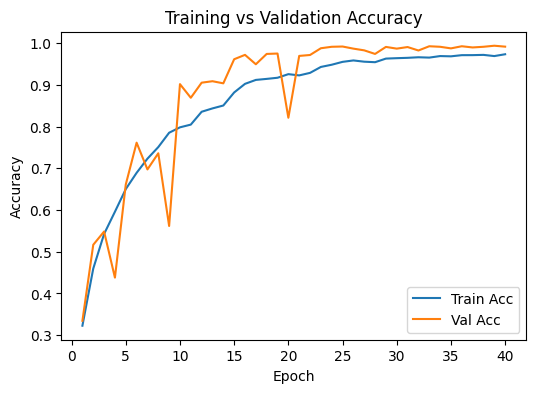

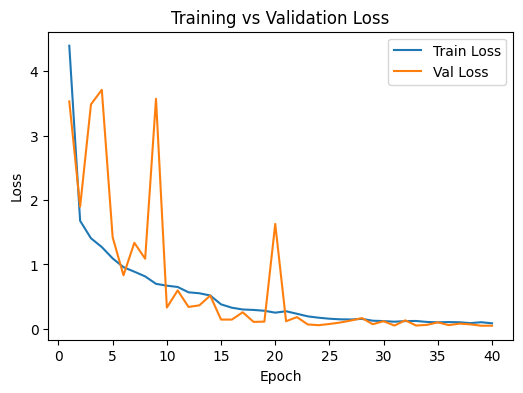

In [ ]:
# Membuat fungsi untuk menampilkan hasil pelatihan
def plot_training(h):
    acc, val_acc = h.history['accuracy'], h.history['val_accuracy']
    loss, val_loss = h.history['loss'], h.history['val_loss']
    epochs = range(1, len(acc)+1)

    # Menampilkan Grafik Akurasi
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title('Training vs Validation Accuracy')
    plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.show()

    # Menampilkan Grafik Loss
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title('Training vs Validation Loss')
    plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

plot_training(history)

## Konversi Model

In [ ]:
# Membuat folder utama untuk menyimpan hasil
export_dir = "exports"
os.makedirs(export_dir, exist_ok=True)

# Menyimpan model dalam format SavedModel
savedmodel_dir = os.path.join(export_dir, "saved_model")
os.makedirs(savedmodel_dir, exist_ok=True)

print("Menyimpan model dalam format SavedModel...")
model.export(savedmodel_dir)
print("SavedModel disimpan di:", savedmodel_dir)

# Menyimpan model dalam format TensorFlow Lite
tflite_dir = os.path.join(export_dir, "tflite")
os.makedirs(tflite_dir, exist_ok=True)

print("\nMengonversi ke format TensorFlow Lite...")
converter = tf.lite.TFLiteConverter.from_saved_model(savedmodel_dir)
tflite_model = converter.convert()

tflite_path = os.path.join(tflite_dir, "model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

# Menambahkan label.txt
with open(os.path.join(tflite_dir, "label.txt"), "w") as f:
    f.write("\n".join(list(test_gen.class_indices.keys())))

print("Model TFLite disimpan di:", tflite_path)

# Menyimpan model dalam format TensorFlow.js
print("\nMengonversi ke format TensorFlow.js...")
!pip install -q tensorflowjs

tfjs_dir = os.path.join(export_dir, "tfjs_model")
os.makedirs(tfjs_dir, exist_ok=True)

!tensorflowjs_converter --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    $savedmodel_dir $tfjs_dir

print("Model TFJS disimpan di:", tfjs_dir)

Menyimpan model dalam format SavedModel...
Saved artifact at 'exports/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  132004195625936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132004181645584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132004181645008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132004181645776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132004181645968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132004181642704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132004181647312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132004181648272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132004181647696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132004181649616: TensorSpec(shape=(),

In [ ]:
# Membuat zip folder exports
!zip -r exports_fzwsp.zip exports

# Download file ZIP
from google.colab import files
files.download('exports_fzwsp.zip')

  adding: exports/ (stored 0%)
  adding: exports/training_log.csv (deflated 58%)
  adding: exports/saved_model/ (stored 0%)
  adding: exports/saved_model/saved_model.pb (deflated 88%)
  adding: exports/saved_model/variables/ (stored 0%)
  adding: exports/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: exports/saved_model/variables/variables.index (deflated 70%)
  adding: exports/saved_model/assets/ (stored 0%)
  adding: exports/saved_model/fingerprint.pb (stored 0%)
  adding: exports/tflite/ (stored 0%)
  adding: exports/tflite/label.txt (deflated 23%)
  adding: exports/tflite/model.tflite (deflated 7%)
  adding: exports/tfjs_model/ (stored 0%)
  adding: exports/tfjs_model/group1-shard4of25.bin (deflated 7%)
  adding: exports/tfjs_model/group1-shard1of25.bin (deflated 7%)
  adding: exports/tfjs_model/group1-shard16of25.bin (deflated 7%)
  adding: exports/tfjs_model/group1-shard11of25.bin (deflated 7%)
  adding: exports/tfjs_model/group1-shard5of25.bin (defla

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference (Optional)

Model TFLite berhasil dimuat.


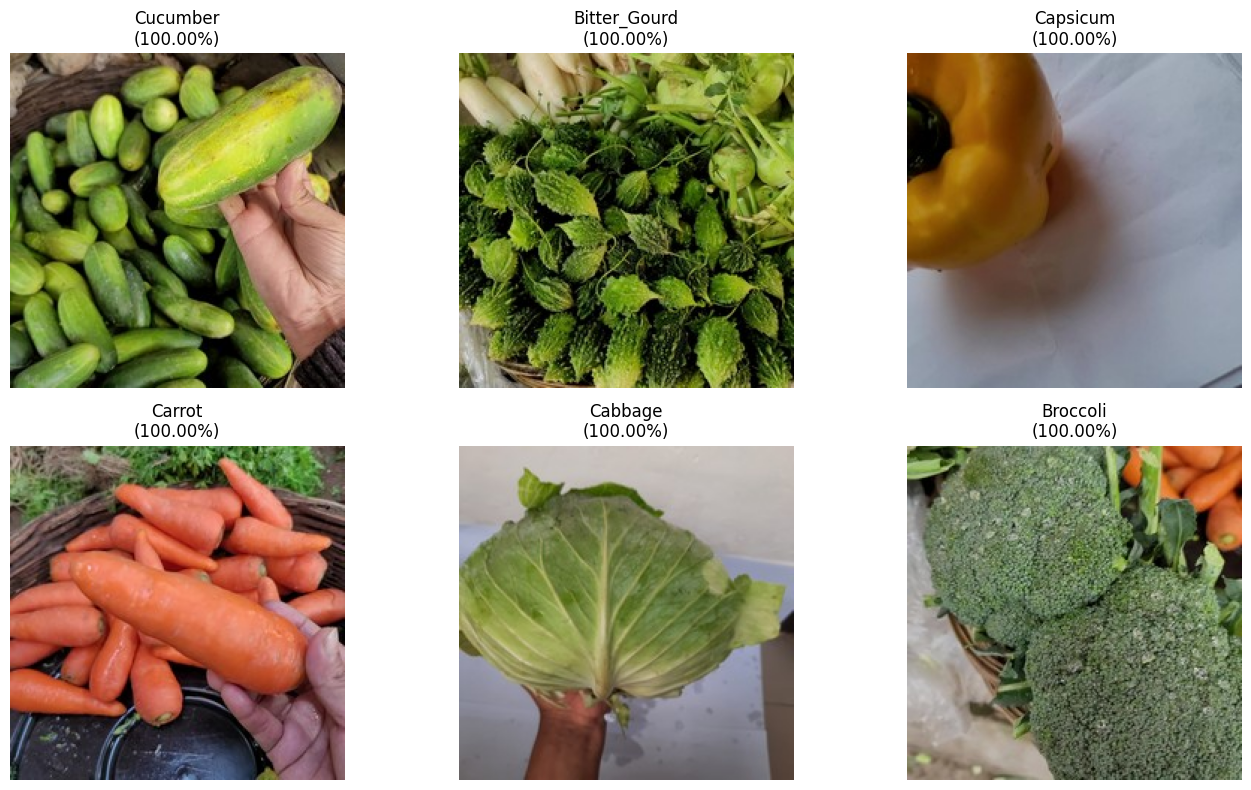

In [ ]:
# Melakukan load model TFLite
tflite_path = "exports/tflite/model.tflite"
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
print("Model TFLite berhasil dimuat.")

# Mengambil informasi input-output tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Menggunakan path dataset test hasil split
test_dir = test_dir
train_dir = train_dir

IMG_SIZE = IMG_SIZE
SAMPLES = 6

# Mapping label mengikuti urutan training
idx_to_class = {v: k for k, v in test_gen.class_indices.items()}

# Mengambil beberapa gambar acak
sample_paths = []
for cls in os.listdir(test_dir):
    cls_path = os.path.join(test_dir, cls)
    if os.path.isdir(cls_path):
        imgs = [
            os.path.join(cls_path, f)
            for f in os.listdir(cls_path)
            if f.lower().endswith(('jpg', 'jpeg', 'png'))
        ]
        sample_paths.extend(imgs)

random.shuffle(sample_paths)
sample_paths = sample_paths[:SAMPLES]

# Melakukan inferensi dan menampilkan hasil
plt.figure(figsize=(14, 8))
for i, path in enumerate(sample_paths, 1):
    img = image.load_img(path, target_size=IMG_SIZE)
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'], x)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_details[0]['index'])[0]

    label = idx_to_class[np.argmax(preds)]
    conf = np.max(preds)

    plt.subplot(2, 3, i)
    plt.imshow(image.load_img(path))
    plt.axis('off')
    plt.title(f"{label}\n({conf*100:.2f}%)")

plt.tight_layout()
plt.show()

Model SavedModel berhasil dimuat


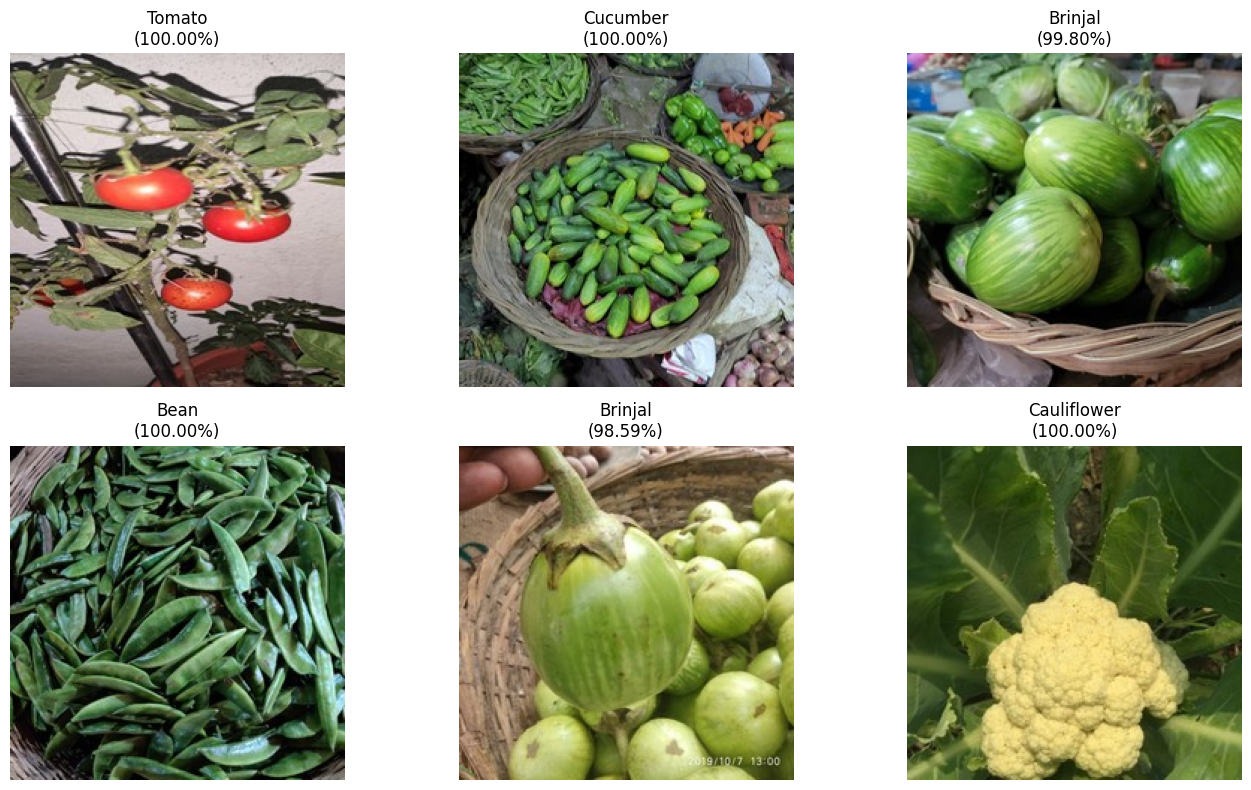

In [ ]:
# Melakukan load model dari folder SavedModel
model_path = "exports/saved_model"
model = TFSMLayer(model_path, call_endpoint="serving_default")
print("Model SavedModel berhasil dimuat")

# Mengambil path dataset test hasil split
train_dir = train_dir
test_dir  = test_dir

IMG_SIZE = IMG_SIZE
SAMPLES  = 6

# Mapping kelas mengikuti hasil training generator
idx_to_class = {v: k for k, v in test_gen.class_indices.items()}

# Mengambil sampel acak dari folder test
sample_paths = []
for cls in os.listdir(test_dir):
    cls_path = os.path.join(test_dir, cls)
    if os.path.isdir(cls_path):
        imgs = [
            os.path.join(cls_path, f)
            for f in os.listdir(cls_path)
            if f.lower().endswith(('jpg','jpeg','png'))
        ]
        sample_paths.extend(imgs)

random.shuffle(sample_paths)
sample_paths = sample_paths[:SAMPLES]

# Melakukan inferensi dan menampilkan hasil
plt.figure(figsize=(14,8))
for i, path in enumerate(sample_paths, 1):
    img = image.load_img(path, target_size=IMG_SIZE)
    x = np.expand_dims(image.img_to_array(img) / 255.0, 0)

    raw = model(x)
    preds = list(raw.values())[0]
    preds = tf.squeeze(preds).numpy()

    label = idx_to_class[np.argmax(preds)]
    conf  = np.max(preds)

    plt.subplot(2, 3, i)
    plt.imshow(image.load_img(path))
    plt.axis("off")
    plt.title(f"{label}\n({conf*100:.2f}%)")

plt.tight_layout()
plt.show()


## README.md dan Requirements

In [ ]:
# Membuat isi file README.md
readme_content = """
# Klasifikasi Gambar Sayuran Menggunakan CNN

Proyek ini membangun model **Convolutional Neural Network (CNN)** untuk mengklasifikasikan gambar sayuran menggunakan dataset *Vegetable Image Dataset*. Dataset diproses secara manual dengan pembagian **70% Train**, **15% Validation**, dan **15% Test**.

Model dikembangkan menggunakan **TensorFlow dan Keras** di Google Colab, kemudian diekspor dalam tiga format berbeda:
- **SavedModel** → untuk deployment backend/server
- **TensorFlow Lite (TFLite)** → untuk aplikasi mobile
- **TensorFlow.js (TFJS)** → untuk digunakan di browser

---

## Langkah Utama Proyek

### 1. Import Dataset dan Split Manual 70/15/15
- Dataset diambil melalui `kagglehub`.
- Semua gambar di-scan dan label diambil dari nama folder.
- Data dibagi menggunakan `train_test_split` dengan stratifikasi.
- Hasil split disalin otomatis ke:
  - `split_data/train/`
  - `split_data/validation/`
  - `split_data/test/`

### 2. Data Generator
Menggunakan `ImageDataGenerator`:
- **train_gen** → augmentasi + normalisasi
- **val_gen** dan **test_gen** → hanya normalisasi (`rescale=1./255`)

Kelas otomatis terdeteksi berdasarkan struktur folder.

### 3. Pembangunan Model CNN
Model menggunakan arsitektur `Sequential` dengan layer:
- `Conv2D`
- `BatchNormalization`
- `MaxPooling2D`
- `Dropout`
- `Flatten`
- `Dense`

Konfigurasi training:
- Optimizer: `Adam(1e-3)`
- Loss: `categorical_crossentropy`
- Metric: `accuracy`

### 4. Training Model
Menggunakan callback:
- **EarlyStopping**
- **ReduceLROnPlateau**
- **ModelCheckpoint** → menyimpan model terbaik ke `exports/best_model.keras`
- **CSVLogger**

Visualisasi:
- Plot akurasi (train vs validation)
- Plot loss (train vs validation)

### 5. Evaluasi Model
Evaluasi dilakukan pada:
- **Train**
- **Validation**
- **Test**

Menghasilkan:
- Accuracy
- Loss
- Classification Report
- Confusion Matrix

### 6. Export Model
Model disimpan dalam tiga format:
- `exports/saved_model/` → SavedModel
- `exports/tflite/model.tflite` → TFLite
- `exports/tfjs_model/` → TensorFlow.js

Selain itu dibuat file:
- `label.txt` → daftar label kelas

### 7. Inferensi
Inferensi dilakukan pada beberapa gambar acak dari folder:
- `split_data/test/`

Model menampilkan:
- Predicted label
- Confidence score
- Visualisasi gambar hasil prediksi

---

## Tools & Library
- TensorFlow
- Keras
- Matplotlib
- NumPy
- Pillow
- scikit-learn
- KaggleHub
- TensorFlow.js converter

---

## Output Utama
- `exports/best_model.keras`
- `exports/saved_model/` → Model untuk server/cloud
- `exports/tflite/model.tflite` → Model untuk mobile (Android/iOS)
- `exports/tfjs_model/` → Model untuk web
- `training_log.csv`
- Grafik akurasi & loss
- Hasil prediksi gambar acak

---

## Lisensi
Dataset berasal dari Kaggle: *Vegetable Image Dataset*.

"""

# Menyimpan file README.md
with open("README.md", "w") as f:
    f.write(readme_content)

print("File 'README.md' berhasil dibuat!")

File 'README.md' berhasil dibuat!


In [ ]:
# Membuat file requirements.txt
!pip freeze > requirements.txt
print("File requirements.txt berhasil dibuat!")

File requirements.txt berhasil dibuat!


In [ ]:
from google.colab import files
files.download("README.md")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>